In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/markerpensseg/train/")
count_images("datasets/markerpensseg/valid")

Total images: 225
Total images: 30


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [3]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.1.0
MMDet: 3.3.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [2]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.24.4

In [2]:
!ls mmdetection/projects/SparseInst/configs/

sparseinst_r50_iam_8xb8-ms-270k_coco.py  sparseinst_r50_markers.py


In [10]:
custom_cfg = """
_base_ = 'sparseinst_r50_iam_8xb8-ms-270k_coco.py'

# Custom classes
dataset_type = 'CocoDataset'
metainfo = dict(classes=("CAP",))
num_classes = 1

vis_backends = [
    dict(type='LocalVisBackend'), # no Tensorboard backend
]
visualizer = dict(
    type='DetLocalVisualizer', vis_backends=vis_backends, name='visualizer')

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/datasets/'
train_ann = data_root + 'markerpensseg/train/_annotations.coco.json'
val_ann = data_root + 'markerpensseg/valid/_annotations.coco.json'
train_img = data_root + 'markerpensseg/train/'
val_img = data_root + 'markerpensseg/valid/'

# Pipelines
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(512, 512), keep_ratio=False),
    dict(type='Pad', size=(512, 512), pad_val=dict(img=(114, 114, 114))),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=True),
    dict(type='PackDetInputs', meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=8,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img=train_img),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline,
        metainfo=dict(classes=("CAP",)),
    )
)

val_dataloader = dict(
    batch_size=8,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img=val_img),
        pipeline=test_pipeline,
        test_mode=True,
        metainfo=dict(classes=("CAP",)),
    )
)

test_dataloader = val_dataloader

# Evaluator
val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'])
# val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox', 'segm'], classwise=True)
test_evaluator = val_evaluator

# Model
model = dict(
    type='SparseInst',
    data_preprocessor=dict(
        type='DetDataPreprocessor',
        mean=[123.675, 116.28, 103.53],
        std=[58.395, 57.12, 57.375],
        bgr_to_rgb=True,
        pad_mask=True,
        pad_size_divisor=32),
    backbone=dict(
        type='ResNet',
        depth=50,
        num_stages=4,
        out_indices=(1, 2, 3),
        frozen_stages=0,
        norm_cfg=dict(type='BN', requires_grad=False),
        norm_eval=True,
        style='pytorch',
        init_cfg=dict(type='Pretrained', checkpoint='torchvision://resnet50')),
    encoder=dict(
        type='InstanceContextEncoder',
        in_channels=[512, 1024, 2048],
        out_channels=256),
    decoder=dict(
        type='BaseIAMDecoder',
        in_channels=256 + 2,
        num_classes=num_classes,
        ins_dim=256,
        ins_conv=4,
        mask_dim=256,
        mask_conv=4,
        kernel_dim=128,
        scale_factor=2.0,
        output_iam=False,
        num_masks=100),
    criterion=dict(
        type='SparseInstCriterion',
        num_classes=num_classes,
        assigner=dict(type='SparseInstMatcher', alpha=0.8, beta=0.2),
        loss_cls=dict(
            type='FocalLoss',
            use_sigmoid=True,
            alpha=0.25,
            gamma=2.0,
            reduction='sum',
            loss_weight=2.0),
        loss_obj=dict(
            type='CrossEntropyLoss',
            use_sigmoid=True,
            reduction='mean',
            loss_weight=1.0),
        loss_mask=dict(
            type='CrossEntropyLoss',
            use_sigmoid=True,
            reduction='mean',
            loss_weight=5.0),
        loss_dice=dict(
            type='DiceLoss',
            use_sigmoid=True,
            reduction='sum',
            eps=5e-5,
            loss_weight=2.0),
    ),
    test_cfg=dict(score_thr=0.005, mask_thr_binary=0.45))

# Schedule
max_iters = 280
interval = 28
train_cfg = dict(
    _delete_=True,
    type='IterBasedTrainLoop',
    max_iters=max_iters,
    val_interval=interval)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# optimizer
optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(_delete_=True, type='AdamW', lr=0.00005, weight_decay=0.05))

# Learning policy
param_scheduler = [
    dict(type='LinearLR', start_factor=0.001, by_epoch=False, begin=0, end=30),
    dict(
        type='MultiStepLR',
        begin=0,
        end=10,
        by_epoch=True,
        milestones=[7, 9],
        gamma=0.1
    )
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=56),
    checkpoint=dict(type='CheckpointHook', interval=56)
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmdetection/mmdet_outputs/sparseinst_r50_markers'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmdetection/v3.0/sparseinst/sparseinst_r50_iam_8xb8-ms-270k_coco/sparseinst_r50_iam_8xb8-ms-270k_coco_20221111_181051-72c711cd.pth'
"""

with open('mmdetection/projects/SparseInst/configs/sparseinst_r50_markers.py', 'w') as f:
    f.write(custom_cfg)

In [ ]:
!python mmdetection/tools/train.py mmdetection/projects/SparseInst/configs/sparseinst_r50_markers.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 15:41:05 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 396454299
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [ ]:
!python mmdetection/tools/test.py mmdetection/projects/SparseInst/configs/sparseinst_r50_markers.py mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/28 15:52:44 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 129123797
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [11]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmdetection/projects/SparseInst/configs/sparseinst_r50_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'

# Run inference
result = inference_detector(model, img)
print(result)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117


Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.pth
<DetDataSample(

    META INFORMATION
    img_shape: (512, 512)
    scale_factor: (0.3333333333333333, 0.25)
    pad_shape: (512, 512)
    ori_shape: (2048, 1536)
    img_path: '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
    img_id: 0
    batch_input_shape: (512, 512)

    DATA FIELDS
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([], device='cuda:0', size=(0, 4))
            masks: BitmapMasks(num_masks=0, height=2048, width=1536)
            labels: tensor([], device='cuda:0', dtype=torch.int64)
        ) at 0x7c9a9527ae10>
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bboxes: tensor([[0., 0., 0., 0.],
                 

/usr/local/lib/python3.11/dist-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.pth


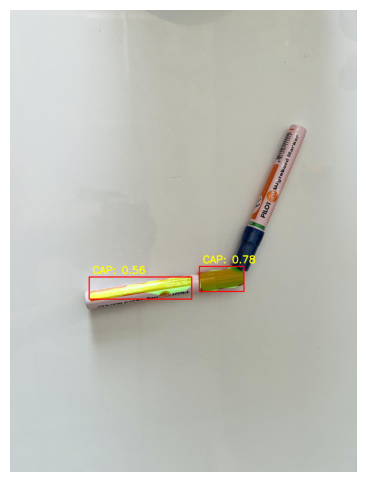

In [12]:
from mmdet.apis import init_detector, inference_detector
from mmdet.structures.mask import BitmapMasks
from mmdet.structures.bbox import HorizontalBoxes
import mmcv
import cv2
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import random

# Class labels
CLASS_LABELS = ["CAP"]

PRED_COLORS = {0: (0, 255, 0)}

# Config and checkpoint paths
config_file = 'mmdetection/projects/SparseInst/configs/sparseinst_r50_markers.py'
checkpoint_file = 'mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

def draw_bbox_with_label(img, bbox, label, score, color=(0, 0, 255), thickness=3):
    xmin, ymin, xmax, ymax = map(int, bbox)
    # Draw rectangle
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)
    # Put label text
    cv2.putText(
        img, f"{label}: {score:.2f}", (xmin + 15, ymin - 15),
        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 255), 3, cv2.LINE_AA
    )

# Image path
img_path = '/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg'
img = cv2.imread(img_path)
if img is None:
    raise Exception("Image not found or unreadable")

# Run inference
results = inference_detector(model, img_path)

# Access the prediction results from the DetDataSample object
pred_instances = results.pred_instances

# 1. Get original image dimensions
ori_h, ori_w = img.shape[:2]

# 2. Extract raw masks (these are currently 512x512 or padded size)
masks_tensor = pred_instances.masks
scores = pred_instances.scores
labels = pred_instances.labels

img_with_masks = img.copy()

for i in range(len(masks_tensor)):
    score = scores[i].item()
    if score < 0.5:
        continue

    # --- THE FIX: Resize the mask to the image size first ---
    # Convert [1, 512, 512] -> [H_original, W_original]
    mask_np = masks_tensor[i].cpu().numpy().astype(np.uint8)
    mask_resized = cv2.resize(mask_np, (ori_w, ori_h), interpolation=cv2.INTER_NEAREST)
    mask_bool = mask_resized > 0

    # --- Now get the box from the RESIZED mask ---
    # Find coordinates where mask is True
    pos = np.where(mask_bool)
    if pos[0].size > 0:
        ymin, xmin = np.min(pos[0]), np.min(pos[1])
        ymax, xmax = np.max(pos[0]), np.max(pos[1])
        bbox = [xmin, ymin, xmax, ymax]
    else:
        continue

    # 3. Draw using the resized mask and the new bbox
    label_id = labels[i].item()
    class_name = CLASS_LABELS[label_id]
    color = PRED_COLORS[label_id]

    colored_mask = np.zeros_like(img, dtype=np.uint8)
    colored_mask[mask_bool] = color
    img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.4, 0)

    draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

# Show result
img_with_bbox_rgb = cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_with_bbox_rgb)
plt.show()

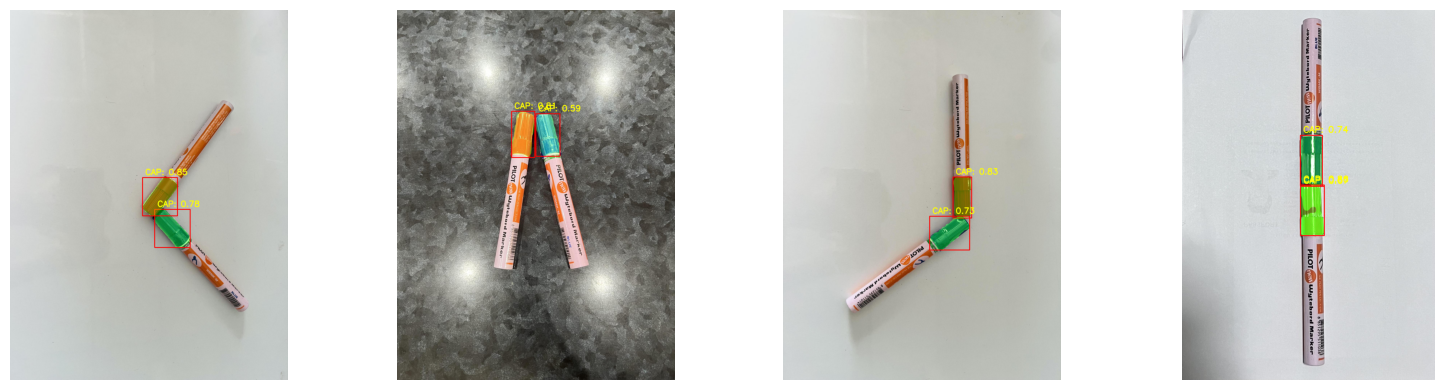

In [ ]:
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    # Access the prediction results from the DetDataSample object
    pred_instances = results.pred_instances

    ori_h, ori_w = img.shape[:2]

    # 2. Extract raw masks (these are currently 512x512 or padded size)
    masks_tensor = pred_instances.masks
    scores = pred_instances.scores
    labels = pred_instances.labels

    img_with_masks = img.copy()

    for i in range(len(masks_tensor)):
        score = scores[i].item()
        if score < 0.5:
            continue

        # --- THE FIX: Resize the mask to the image size first ---
        # Convert [1, 512, 512] -> [H_original, W_original]
        mask_np = masks_tensor[i].cpu().numpy().astype(np.uint8)
        mask_resized = cv2.resize(mask_np, (ori_w, ori_h), interpolation=cv2.INTER_NEAREST)
        mask_bool = mask_resized > 0

        # --- Now get the box from the RESIZED mask ---
        # Find coordinates where mask is True
        pos = np.where(mask_bool)
        if pos[0].size > 0:
            ymin, xmin = np.min(pos[0]), np.min(pos[1])
            ymax, xmax = np.max(pos[0]), np.max(pos[1])
            bbox = [xmin, ymin, xmax, ymax]
        else:
            continue

        # 3. Draw using the resized mask and the new bbox
        label_id = labels[i].item()
        class_name = CLASS_LABELS[label_id]
        color = PRED_COLORS[label_id]

        colored_mask = np.zeros_like(img, dtype=np.uint8)
        colored_mask[mask_bool] = color
        img_with_masks = cv2.addWeighted(img_with_masks, 1.0, colored_mask, 0.4, 0)

        draw_bbox_with_label(img_with_masks, bbox, class_name, score, color=(0, 0, 255))

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 134.3 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!

In [5]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 7.0 MB/s eta 0:00:00


In [13]:
import torch

In [14]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [25]:
import torch.nn as nn
import torch.nn.functional as F

def forward(self, x):
    # Detect feature map size and set fixed kernels
    # Input 512 -> FPN levels: 64x64, 32x32, 16x16
    h = x.shape[-2]

    # If feature map is 16x16 and we want 1x1 output -> kernel is 16
    # This avoids the "Calculated output size: 0" error
    return F.avg_pool2d(x, kernel_size=(h, h))

nn.AdaptiveAvgPool2d.forward = forward

In [26]:
dummy_input = torch.randn(1, 3, 512, 512).to(device)
onnx_model_path = "mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_model_path,
    opset_version=11,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
)
print(f"ONNX export {onnx_model_path} completed successfully!")

============= Diagnostic Run torch.onnx.export version 2.0.1+cu117 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX export mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.onnx completed successfully!


In [121]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/1B3246F6-8785-4465-AC56-3BE7AA44003D_jpeg.rf.ddd6b9b6921d9589dfae0019661b06a1.jpg"

mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (512, 512))
img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 100, 1), (1, 100, 128, 128), (1, 100, 1)]


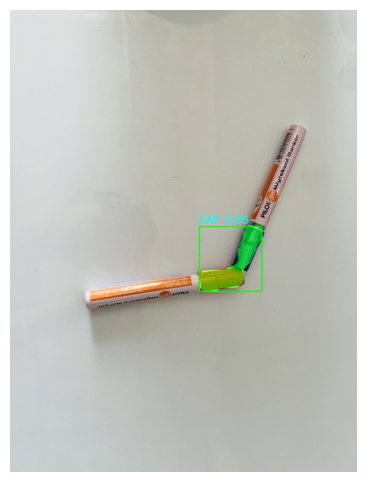

In [138]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def sigmoid(x):
    # Clip values to [-20, 20] to prevent exp overflow
    # np.exp(20) is ~485 million, safe for float64/float32
    x = np.clip(x, -20, 20)
    return 1 / (1 + np.exp(-x))

CLASS_LABELS = ['CAP']
CONF_THRESHOLD = 0.5
MASK_THRESHOLD = 0.5

# 1. Unpack ONNX outputs (100, 1) and (100, 128, 128)
cls_logits = outputs[0][0]
mask_logits = outputs[1][0]
obj_logits = outputs[2][0]

# --- THE FIX: Apply Sigmoid to the Scores ---
cls_probs = sigmoid(cls_logits)
obj_probs = sigmoid(obj_logits)
final_scores = cls_probs * obj_probs

orig_h, orig_w = img.shape[:2]
img_with_results = img.copy()

# Track already detected pixels to block "big merged boxes"
combined_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

# Sort to process highest scores first
indices = np.argsort(final_scores.flatten())[::-1]

for i in indices:
    score = float(final_scores[i])
    if score < CONF_THRESHOLD:
        continue

    mask_raw = sigmoid(mask_logits[i])
    mask_full = cv2.resize(mask_raw, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    mask_binary = (mask_full > MASK_THRESHOLD).astype(np.uint8)

    # --- THE FLOW FIX: Skip if this mask is mostly covering a better detection ---
    # This prevents the "big box" from overwriting individual marker boxes
    if np.sum(mask_binary & combined_mask) > np.sum(mask_binary) * 0.5:
        continue

    coords = np.argwhere(mask_binary > 0)
    if coords.size == 0:
        continue

    y1, x1 = coords.min(axis=0)
    y2, x2 = coords.max(axis=0)

    # Add this mask to the tracker
    combined_mask |= mask_binary

    # --- Step C: Visualization ---
    color = (0, 255, 0)
    mask_visual = np.zeros_like(img_with_results)
    mask_visual[mask_binary == 1] = color
    img_with_results = cv2.addWeighted(img_with_results, 1.0, mask_visual, 0.6, 0)

    cv2.rectangle(img_with_results, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img_with_results, f"{CLASS_LABELS[0]} {score:.2f}", (x1, y1 - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

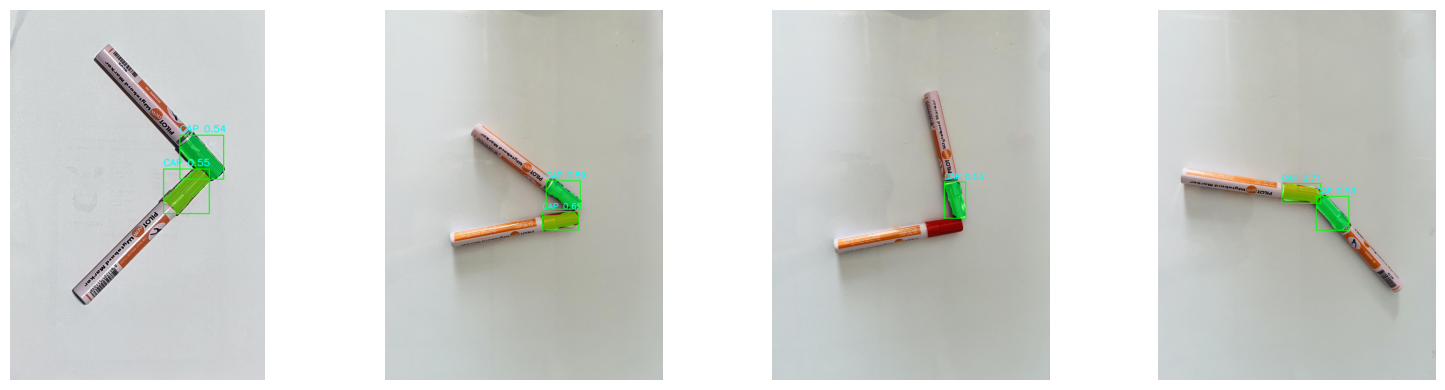

In [140]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/Pytorch-Models/datasets/markerpensseg/valid/"

def sigmoid(x):
    # Clip values to [-20, 20] to prevent exp overflow
    # np.exp(20) is ~485 million, safe for float64/float32
    x = np.clip(x, -20, 20)
    return 1 / (1 + np.exp(-x))

CLASS_LABELS = ['CAP']
CONF_THRESHOLD = 0.5
MASK_THRESHOLD = 0.5

session = onnxruntime.InferenceSession("mmdetection/mmdet_outputs/sparseinst_r50_markers/iter_280.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name

# visualization layout
N = 4
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 4 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(1, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (512, 512))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    cls_logits = outputs[0][0]
    mask_logits = outputs[1][0]
    obj_logits = outputs[2][0]

    # --- THE FIX: Apply Sigmoid to the Scores ---
    cls_probs = sigmoid(cls_logits)
    obj_probs = sigmoid(obj_logits)
    final_scores = cls_probs * obj_probs

    orig_h, orig_w = img.shape[:2]
    img_with_results = img.copy()

    # Track already detected pixels to block "big merged boxes"
    combined_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

    # Sort to process highest scores first
    indices = np.argsort(final_scores.flatten())[::-1]

    for i in indices:
        score = float(final_scores[i])
        if score < CONF_THRESHOLD:
            continue

        mask_raw = sigmoid(mask_logits[i])
        mask_full = cv2.resize(mask_raw, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
        mask_binary = (mask_full > MASK_THRESHOLD).astype(np.uint8)

        # --- THE FLOW FIX: Skip if this mask is mostly covering a better detection ---
        # This prevents the "big box" from overwriting individual marker boxes
        if np.sum(mask_binary & combined_mask) > np.sum(mask_binary) * 0.5:
            continue

        coords = np.argwhere(mask_binary > 0)
        if coords.size == 0:
            continue

        y1, x1 = coords.min(axis=0)
        y2, x2 = coords.max(axis=0)

        # Add this mask to the tracker
        combined_mask |= mask_binary

        # --- Step C: Visualization ---
        color = (0, 255, 0)
        mask_visual = np.zeros_like(img_with_results)
        mask_visual[mask_binary == 1] = color
        img_with_results = cv2.addWeighted(img_with_results, 1.0, mask_visual, 0.6, 0)

        cv2.rectangle(img_with_results, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_with_results, f"{CLASS_LABELS[0]} {score:.2f}", (x1, y1 - 15),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_results, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()